# Neural Networks for Data Science
## End-of-term homework: KV Cache handling and compression

**Name**: *Leonardo Rocci*

**Matricola**: *1922496*

> ✍ Upload the completed notebook **at least three days** before your expected exam's date on the Google Classroom page. For example, for the **January 12th** session, you should upload it by **January 9th, 23:59 Rome time**.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrand
import matplotlib.pyplot as plt

### Instructions

1. The homework has two exercises, only the first one is mandatory to access the oral exam.
2. The second exercise is graded (4 points). Without it, the maximum mark for the oral will be 26.
3. Lode requires *exceptional* solutions and orals (top 5%).
4. If you score well on the project but poorly on the oral, the grade can be kept for the entire academic year (up to October 2026).

**IMPORTANT - read carefully before starting**:

> 🟨 *External material*: if you use external material (including AI tools), reference it *explicitly* in the corresponding cell. Copy-paste *is not allowed*.

> 🔵 *Grammar*: please try to be precise and provide nice-to-read descriptions.

> 🟥 *JAX*: the homework must be done _in JAX_ or high-level JAX libraries (Haiku, Flax, equinox, ...). You cannot use libraries that directly solve the core exercise(s). When in doubt, ask.

> 🟪 *Math*: you can use LaTeX in Markdown if you need to write equations or if you need generic math notation.


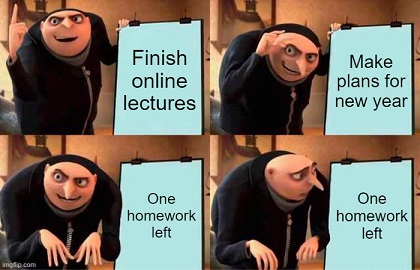

## Warmup: Data loading

For this part, select a dataset that you like, keeping in mind task complexity with respect to the available hardware.

*   You can use any data processing you want (PyTorch data loaders, TensorFlow datasets, Grain, HuggingFace Dataset, ...).
*   Any data type (tabular, images, videos, audio, time-series, graphs, ...) is okay.

A few repositories that you can look at:

1. The catalog of [TensorFlow Datasets](https://www.tensorflow.org/datasets/).
2. The [Kaggle catalog](https://www.kaggle.com/data). For downloading data from Kaggle on Google Colab, you will need to [load your Kaggle authentication token](https://colab.research.google.com/github/corrieann/kaggle/blob/master/kaggle_api_in_colab.ipynb).
3. The [UCI Machine Learning Repository](https://archive.ics.uci.edu/datasets).
4. The [🤗 HuggingFace Datasets](https://huggingface.co/docs/datasets/) repository.

You are not bound to these; any open repository is okay. The choice of dataset will not influence the mark.

✍ **DESCRIPTION OF THE CODE**

### A. **Dataset Description and Initial Analysis**

For this exercise, we utilize the **Rotten Tomatoes Critic Reviews Dataset**. The task is a binary sentiment classification problem where each movie review must be evaluated and labeled as either positive ("fresh") or negative ("rotten"). 

To understand the shape of our data, we first analyze the raw text lengths and the class distribution.

In [2]:
from src.data_analysis import analyze_dataset

analyze_dataset("data/rotten_tomatoes_critic_reviews.csv")

Loading dataset from: data/rotten_tomatoes_critic_reviews.csv

--- Dataset Columns ---
['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']

Using Text Column: review_content
Using Label Column: review_type

--- Basic Statistics ---
Total reviews: 1130017

--- Review Type Distribution ---
Fresh: 720210 (63.73%)
Rotten: 409807 (36.27%)

--- Missing Values ---
Missing text (review_content): 65806 (5.82%)
Missing labels (review_type): 0 (0.00%)

--- Text Length Analysis (in characters) ---
Minimum length: 1
Maximum length: 258
Average length: 128.01

--- Text Length Analysis (in approximate words - split by space) ---
Minimum words: 1
Maximum words: 55
Average words: 21.34

--- Sample Reviews ---
Fresh:
  A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will thri...
Rotten:
  What's really lacking in The Lightning Th

### B. **Preprocessing and Sequence Formatting**

To frame this as a causal language modeling task, the raw data requires structural formatting. We perform two main preprocessing steps:

1. **Lowercasing:** All reviews are converted to lowercase. For a Small Language Model (SLM) with a highly restricted parameter budget, lowercasing prevents the tokenizer from wasting precious vocabulary slots on capitalized duplicates of common words, thereby minimizing word fragmentation.
2. **Special Tokens and Formatting:** We inject structural markers to guide the model's autoregressive generation:
    * `[SOS]` / `[EOS]`: Start and End of Sequence markers.
    * `[SOR]`: Start of Reasoning. This cleanly separates the input review from the model's generation phase.
    * `[RP]`: Reasoning Placeholders. Instead of jumping straight to the classification, we force the model to generate a sequence of dummy tokens. While in a real-world scenario this would represent a Chain-of-Thought reasoning path, here it artificially extends the decoding phase to provide a measurable window for testing the latency improvements of our custom KV Cache. Additionally, requiring the model to output a specific number (15) of these placeholders creates an implicit counting task. This serves as a secondary structural benchmark to evaluate how different caching techniques impact the model's stability and generation accuracy.
    * `[SEN]`: Sentiment prompt token, signaling the end of reasoning and the start of the final classification.
    * `[FRE]` / `[ROT]`: The binary classification target tokens mapped from the "fresh" and "rotten" labels.

The final sequence follows this strict template: `[SOS] <review text> [SOR] [RP]... [SEN] [FRE]/[ROT] [EOS]`.

In [3]:
from src.data_processing import process_dataset

process_dataset(
    input_path="data/rotten_tomatoes_critic_reviews.csv", 
    output_path="data/processed_reviews.csv", 
    num_reasoning_tokens=15
)

Loading dataset from: data/rotten_tomatoes_critic_reviews.csv
Dropped 65806 rows with missing content/type. Remaining: 1064211

Fresh: 63.99%
Rotten: 36.01%

Formatting reviews...

--- Length Analysis of Processed Text (in words) ---
Minimum length: 21 words
Maximum length: 75 words
Average length: 41.34 words

Saving formatted dataset to: data/processed_reviews.csv
Done!

Sample formatted review:
{'formatted_review': '[SOS] a fantasy adventure that fuses greek mythology to contemporary american places and values. anyone around 15 (give or take a couple of years) will thrill to the visual spectacle [SOR] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [SEN] [FRE] [EOS]', 'is_fresh': True}


### C. **Tokenization and Vocabulary Analysis**

Before training a Byte-Pair Encoding (BPE) tokenizer, we must determine the optimal vocabulary size. The vocabulary size dictates the size of our input embedding matrix and heavily influences how severely natural words are fragmented into subwords.

In [6]:
from src.tokenizer_dev import analyze_vocab_sizes

# Evaluate how different vocabulary sizes impact word fragmentation and sequence length
analyze_vocab_sizes("data/processed_reviews.csv", vocab_sizes=[1000, 2500, 5000, 10000])

Loading dataset from: data/processed_reviews.csv
Average words per review: 41.34 (Max: 75, Min: 21)


Analyzing Vocab Configs:   0%|          | 0/4 [00:00<?, ?it/s]


Vocab Size   | Avg Tokens   | Max Tokens   | Min Tokens   | Tokens/Word
--------------------------------------------------------------------------------
1000         | 64.08        | 267          | 21           | 1.55
2500         | 55.84        | 267          | 21           | 1.35
5000         | 51.76        | 267          | 21           | 1.25
10000        | 48.98        | 225          | 21           | 1.18

Sample Review Comparison (Original: 49 words)
--------------------------------------------------------------------------------
Vocab 1000   ->  [SOS] | a | f | ant | as | y | ad | vent | ure | that | f | us | es | gre | e | k | my | tho | lo | gy | to | cont | em | por | ary | american | pla |...
Vocab 2500   ->  [SOS] | a | fantasy | adventure | that | f | uses | gre | ek | my | tho | logy | to | contem | por | ary | american | pla | ces | and | val | ues | . ...
Vocab 5000   ->  [SOS] | a | fantasy | adventure | that | f | uses | gre | ek | my | thology | to | contemporary | a

**Vocabulary Size Selection:**
We select a vocabulary size of **5,000**. While evaluating different sizes, we observed diminishing returns in the fragmentation gap when scaling from 5,000 up to 10,000 tokens. This vocabulary provides a highly efficient middle ground, yielding semantically meaningful and cohesive tokens while preserving more parameters for the hidden layers of the Transformer architecture. Furthermore, empirical tests showed that training is approximately 20% faster at 5,000 compared to 10,000, as the smaller vocabulary size reduces the overhead in the model's final dense projection layer.

**Sequence Length and Dataset Preparation:**
We set the maximum sequence length to **128** tokens. Only a tiny fraction of the processed dataset exceeds this threshold, allowing us to safely drop those rare outliers without meaningful data loss. This choice yields massive performance gains: because self-attention computation scales quadratically with sequence length ($O(L^2)$), halving the context window from 256 to 128 theoretically reduces the attention compute footprint by up to 75%, with an observed real-world training time reduction of approximately 50%. 

With these parameters locked in, the final pipeline trains the tokenizer, encodes the dataset, right-pads all sequences to exactly 128 tokens, and stratifies the splits (80% Train, 10% Validation, 10% Test). The fully integer-encoded sequences are exported as `.npy` arrays to guarantee instantaneous, bottlenecKfree loading during the training loop.

In [ ]:
from src.tokenizer_dev import pretokenize_dataset

# Train final tokenizer, encode, pad, and save memory-mapped splits
pretokenize_dataset(
    data_path="data/processed_reviews.csv",
    output_dir="data",
    vocab_size=5000,
    max_seq_len=128,
    splits=(0.8, 0.1, 0.1)
)

Loading dataset from: data/processed_reviews.csv...
Training BPE Tokenizer (Vocab Size: 5000)...



Encoding reviews...
Dropped 73/1064211 (0.01%) sequences exceeding 128 tokens.
Dataset split: Train 80.0% / Val 10.0% / Test 10.0%
Done! Train: (851310, 128), Val: (106413, 128), Test: (106415, 128)


## Exercise 1: KV Cache (mandatory)

**KV caching** is a mechanism implemented in autoregressive transformer models, wherein previous key and value computations are stored and reused when predicting a new token (see book, Chapter 11) and [this blog post](https://magazine.sebastianraschka.com/p/coding-the-kv-cache-in-llms).

> 🟨 Required reading before proceeding: [https://jax-ml.github.io/scaling-book/inference/](https://jax-ml.github.io/scaling-book/inference/).

**TODO**: Write and test a variant of multi-head attention with an internal KV cache mechanism. This is mostly didactical, so you should not concern too much with speed and efficiency (very difficult to achieve in practice).

💡 *Hint*: Start by coding the MHA layer and then add the KV Caching mechanism.

✍ **DESCRIPTION OF THE CODE**

### 1.1. **Model Architecture and Training**

**Model Architecture**
We implemented a custom Causal Decoder-only Language Model. It features standard Transformer blocks consisting of Layer Normalization, a custom Multi-Head Causal Self-Attention mechanism, and an MLP expansion layer. 

**Training Setup**
The model is trained via next-token prediction using cross-entropy loss. We set the training to run for a maximum of 50 epochs. To prevent overfitting and reduce training time, we employ an early stopping mechanism tied to the validation loss with a patience of 2 epochs (actually early stopping was never triggered, resulting in a total training time of $\approx$ 13 hours 🥲). 

In [4]:
from src.train import train_slm

# model, history = train_slm(
#     data_dir="data",
#     tokenizer_path="data/tokenizer.json",
#     max_epochs=50,
#     patience=2,
#     batch_size=128,
#     learning_rate=3e-4,
#     d_model=128,      
#     num_heads=4,      
#     num_layers=6,     
#     mlp_hidden=512,
#     # max_steps=10      # Halts epoch early for testing
# )

Loading tokenizer and finding special IDs...
Vocab size: 5000, Max Sequence Length: 127

Starting Training Loop...


Epoch 001 [Train]:   0%|          | 0/6651 [00:00<?, ?it/s]

Epoch 001 [Val]:   0%|          | 0/832 [00:00<?, ?it/s]

Epoch 001 | Train: L=3.2405 Ppl=32.76 Acc=65.44% | Val: L=2.8794 Ppl=17.83 Acc=71.76%


Epoch 002 [Train]:   0%|          | 0/6651 [00:00<?, ?it/s]

...

Epoch 049 [Val]:   0%|          | 0/832 [00:00<?, ?it/s]

Epoch 049 | Train: L=2.3701 Ppl=10.71 Acc=83.75% | Val: L=2.4209 Ppl=11.27 Acc=83.27%


Epoch 050 [Train]:   0%|          | 0/6651 [00:00<?, ?it/s]

Epoch 050 [Val]:   0%|          | 0/832 [00:00<?, ?it/s]

Epoch 050 | Train: L=2.3687 Ppl=10.70 Acc=83.75% | Val: L=2.4207 Ppl=11.27 Acc=83.44%
Training Complete.


Training plot saved to assets/training_plot_50epochs.png


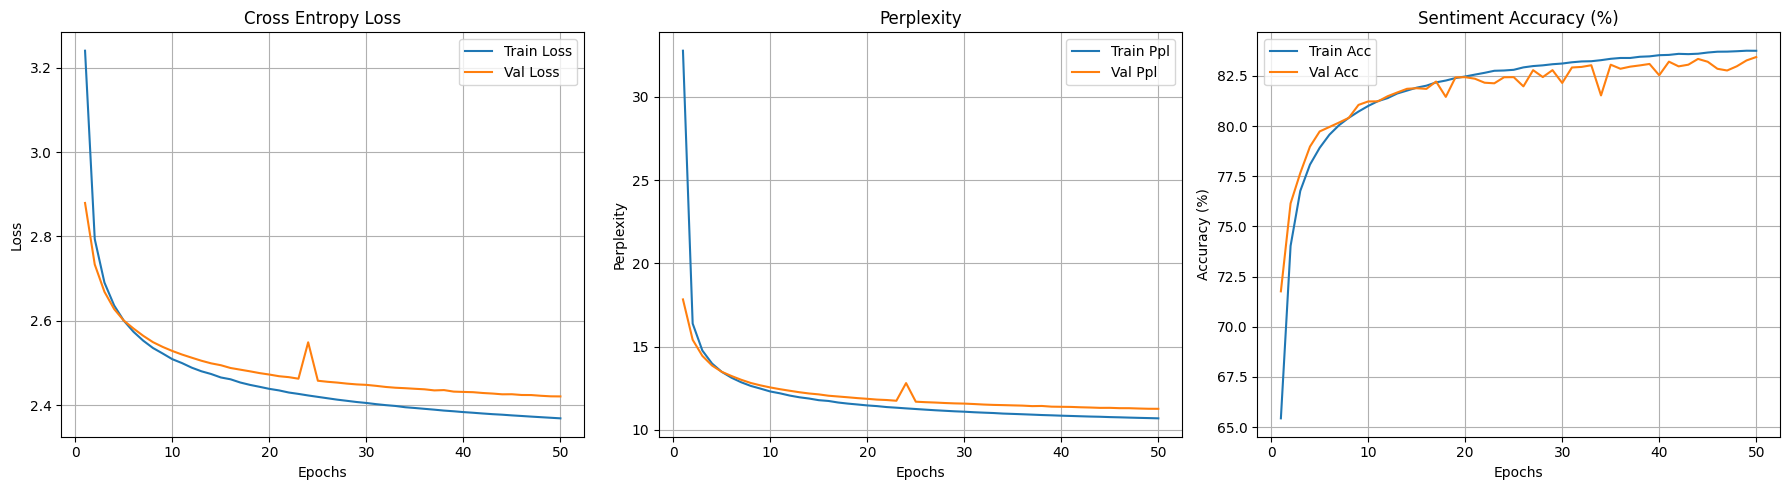

In [5]:
import pickle
from src.train import plot_training_history

# with open('assets/training_history_50epochs.pkl', 'wb') as f:
#     pickle.dump(history, f)

with open('assets/training_history_50epochs.pkl', 'rb') as f:
    loaded_history = pickle.load(f)



plot_training_history(loaded_history, save_path="assets/training_plot_50epochs.png")

### 1.2. **Evaluation on Test Dataset**

To establish a baseline for both accuracy and generation speed, we first evaluate the model on the entire test dataset with KV caching explicitly disabled.

**Inference Engine Logic**
The `run_inference` pipeline evaluates the model using an autoregressive loop:
* **The Starting Point:** The script locates the `[SOR]` (Start of Reasoning) token in each prompt. It explicitly erases all ground truth tokens that follow it, forcing the model to generate the reasoning and sentiment phases completely blindly.
* **Batch Processing:** To achieve high throughput, generation is batched using `jax.vmap`. Instead of left-padding prompts of different lengths, the script dynamically tracks the index of `[SOR]` for every sequence in the batch and inserts the newly generated token at the correct offset position.
* **Caching:** In this baseline run (`use_cache=False`), the model performs a full forward pass over the entire sequence history at every single step.
* **Evaluation Metrics:** The engine verifies the structural integrity of every sequence first. It checks for the presence of `[SEN]` and `[EOS]`, and strictly counts if exactly 15 `[RP]` tokens were generated. It then calculates sentiment accuracy by checking if the token immediately following `[SEN]` matches the ground truth (`[FRE]` or `[ROT]`).


In [3]:
from src.predict import run_inference

run_inference(
    model_weights="best_model_50.eqx",
    use_cache=False
);

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


INFERENCE RESULTS
Total Samples  : 106415
Model File     : best_model_50.eqx
KV Caching     : DISABLED
Throughput     : 4422.59 tokens/sec
--------------------------------------------------
STRUCTURAL METRICS:
Generated [EOS]: 1 sequences (0.00%) failed missing EOS.
Generated [SEN]: 1 sequences (0.00%) failed missing SEN.
Generated [RP] : 2 sequences (0.00%) failed to form exactly 15 [RP] tokens.
--------------------------------------------------
SENTIMENT ACC. : 83.40% (81.89% bal.) (over all samples)
CONDITIONAL ACC: 83.40% (81.89% bal.) (where valid sentiment exists)

=== EXAMPLES OF BAD [RP] TOKEN SEQUENCES ===

Example 1:
[SOS] gi os toy bar ry lev inson , al la m all on o x i idi a it era pro se k ti k os ma th h th s toy , o sam so y an am as a e i sen ario gra fi ka ka i so y y po b ath m ize i sk h no the ti ka ol a ay ta ta psy x op sa x ti ka po y exe is syn h this e i na ble pe is sta ane ks arth ta amer i k an i ka [SOR] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [

**Analysis of Results**

The model successfully generalized its training to open ended autoregressive generation. The test sentiment accuracy of **83.40%** perfectly aligns with the train and val accuracy observed during training. This is a crucial validation step, as the training phase only evaluated the model using single step next token prediction, whereas this inference loop proves the model can maintain its trajectory over a long sequence of autonomous generation.

Furthermore, the model learned the structural constraints almost flawlessly. Out of 106,415 sequences, it failed to generate the correct structural format only twice. Looking at the two failed examples, the prompts consist of transliterated Greek ("Greeklish"). Because this syntax is completely out of distribution compared to standard English reviews, the model's attention mechanism destabilized. In the first case, it overshot the reasoning phase and generated 18 `[RP]` tokens. In the second case, it completely missed the `[SEN]` token and hallucinated random text.

Finally, the baseline generation speed is established at $\approx 4400$ tokens/sec. We will use this benchmark to quantify the latency improvements when testing the custom KV Cache mechanics in the next section.

### 1.3. **KV Caching**

**Implementation Challenges in JAX**

The most straightoforward way to implement KV cachign would be by dynamically concatenating arrays at every step. However, JAX's Just-In-Time (`@eqx.filter_jit`) compiler requires strictly static, unchanging tensor shapes to build its XLA graphs. A dynamically growing cache array would force JAX to continuously recompile the computation graph, destroying generation speed (as we observed).

To bypass this, we implemented a static memory allocation strategy:
1. **Prefill Phase:** We pre-allocate fixed size arrays (padded to the maximum sequence length of 128) and process the entire prompt to fill the initial cache.
2. **Static Decoding:** We added a `cache_index` pointer to the state. During generation, we use `jax.lax.dynamic_update_slice` to overwrite exactly one specific row of the pre-allocated cache tensor without changing its overall dimensions.

In [2]:
run_inference(
    model_weights="best_model_50.eqx",
    use_cache=True
);

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


INFERENCE RESULTS
Total Samples  : 106415
Model File     : best_model_50.eqx
KV Caching     : ENABLED
Throughput     : 13419.69 tokens/sec
--------------------------------------------------
STRUCTURAL METRICS:
Generated [EOS]: 1 sequences (0.00%) failed missing EOS.
Generated [SEN]: 1 sequences (0.00%) failed missing SEN.
Generated [RP] : 2 sequences (0.00%) failed to form exactly 15 [RP] tokens.
--------------------------------------------------
SENTIMENT ACC. : 83.40% (81.89% bal.) (over all samples)
CONDITIONAL ACC: 83.40% (81.89% bal.) (where valid sentiment exists)

=== EXAMPLES OF BAD [RP] TOKEN SEQUENCES ===

Example 1:
[SOS] gi os toy bar ry lev inson , al la m all on o x i idi a it era pro se k ti k os ma th h th s toy , o sam so y an am as a e i sen ario gra fi ka ka i so y y po b ath m ize i sk h no the ti ka ol a ay ta ta psy x op sa x ti ka po y exe is syn h this e i na ble pe is sta ane ks arth ta amer i k an i ka [SOR] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [RP] [

**Analysis of Results**

As expected, the sentiment accuracy and structural metrics remain perfectly identical to the baseline run. KV Caching is strictly a memory and compute optimization; it does not approximate or alter the mathematical outcome of the attention mechanism.

The critical difference is the generation speed. By eliminating the redundant recalculation of historical tokens, the generation throughput skyrocketed from $\approx 4,400$ tokens/sec to over $13,000$ tokens/sec, delivering a 3x performance improvement.

## Exercise 2: KV Cache compression (4 points)

**KV cache compression** algorithms try to dinamically reduce the size of the KV cache by, e.g., removing key/value pairs, or compressing them to a reduced set of tokens. See [this paper](https://arxiv.org/abs/2406.11430) for an introduction, and the [kvpress](https://github.com/NVIDIA/kvpress) library from NVIDIA for practical implementations (in PyTorch).

**TODO**: Reimplement (and test) one of the methods from the KVPress library (e.g., `KnormPress`).

✍ **DESCRIPTION OF THE CODE**

### 2.0 **Implementation note**

Implementing token eviction in JAX requires working around strict compilation rules. JAX `jit` demands static tensor shapes, meaning we cannot physically shrink a sequence from 128 tokens down to 30. Instead, we implement "logical" compression. The physical cache array remains a fixed 128 slots, but we manipulate a `cache_index` pointer and overwrite specific memory slots to densely pack the surviving tokens. 

During development, we encountered several quirks. For example, static conditions caused "padding avalanches" where the compressor would forcefully select `<PAD>` tokens to fill its budget. We solved this by zeroing out padding upstream and dynamically checking the actual sequence length to bypass compression on short prompts. Furthermore, we discovered the model instantly collapses if it loses its starting anchor. To solve this, we artificially set the score of the `[SOS]` token to infinity so the sorting algorithms are mathematically forced to protect it.

### 2.1. **Random Compression Baseline**

In [1]:
from src.benchmark_compression import run_compression_benchmark
from src.compression import RandomCompressor

To understand how advanced algorithms perform, we first need a naive baseline. The `RandomCompressor` assigns uniformly random noise to every valid token in the sequence and uses a `top_k` operation to keep the tokens with the highest random scores. For this test, the compressor operates exclusively during the prefill phase and protects the `[SOS]` token from eviction.

Beyond serving as a performance floor, this random baseline proved invaluable for debugging. Because the outcomes of its random behavior are predictable, it acted as a perfect diagnostic control variable. When structural anomalies appeared in our initial tests, such as higher performance at a lower budget, the Random Compressor allowed us to isolate these issues as bugs rather than failures of the compression heuristic. If we had started our debugging process with e.g. SnapKV, these silent logical quirks would have been easily misinterpreted as flaws of the specific technique and would have been significantly harder to track down and correct.

#### 2.1.1. **Vanilla Compression**

In [23]:
experiment_configs = [
        {"budget": k, } 
        for k in [100, 30, 10, 3]
    ]
bench_rand = run_compression_benchmark(RandomCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[2/4] Benchmarking Config: {'budget': 30}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[3/4] Benchmarking Config: {'budget': 10}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[4/4] Benchmarking Config: {'budget': 3}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


COMPRESSION BENCHMARK SUMMARY
          Method  budget Sentiment Acc (%) Cond. Acc (%)   Missing EOS   Missing SEN   Bad RP Count
RandomCompressor     100       83.4 (81.9)   83.4 (81.9)      1 (0.0%)      1 (0.0%)       2 (0.0%)
RandomCompressor      30       81.8 (80.6)   81.9 (80.6)     49 (0.0%)     27 (0.0%)  17518 (16.5%)
RandomCompressor      10       70.0 (68.9)   74.9 (73.8)   7719 (7.3%)   6056 (5.7%)  70395 (66.2%)
RandomCompressor       3       47.8 (45.6)   65.2 (62.2) 30830 (29.0%) 25660 (24.1%) 100012 (94.0%)



The benchmark reveals an interesting dichotomy between structural integrity and semantic classification. While formatting begins to significantly degrade at a budget of 10 (with a 66.2% Bad RP Count), the overall classification performance drops far less severely compared to higher budgets. Note that the scores in parentheses denote the balanced accuracy, which is crucial for properly evaluating true performance on our unbalanced dataset. 

Remarkably, even at an extremely restrictive budget of 3, the conditional accuracy (the model's accuracy when it successfully outputs a valid sentiment) sits at 65.2% (62.2% balanced). This is still better than a random guess. This resilience indicates that the sentiment analysis task requires relatively little continuous context. Because sentiment-bearing words exhibit high redundancy throughout a movie review, randomly sampling just a handful of words is sometimes sufficient for the model to correctly deduce the overall polarity.

#### 2.1.2. **Protecting the `SOR` token**

We argue that the main signal for the model's correct formatting is given by the `[SOR]` (Start of Reasoning) token. The naive random baseline blindly evicts this token, which strips the model of its structural prompt and leads to the massive formatting failures seen at lower budgets. To test this hypothesis, we applied the same "Infinity Trick" used for the `[SOS]` token to guarantee the `[SOR]` anchor is always preserved in the compressed cache. 

The following benchmark demonstrates the impact of explicitly protecting the `[SOR]` token:

In [24]:
experiment_configs = [
        {"budget": k, 'protect_sor':True } 
        for k in [100, 30, 10, 3]
    ]
bench_rand_ps = run_compression_benchmark(RandomCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100, 'protect_sor': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[2/4] Benchmarking Config: {'budget': 30, 'protect_sor': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[3/4] Benchmarking Config: {'budget': 10, 'protect_sor': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[4/4] Benchmarking Config: {'budget': 3, 'protect_sor': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


COMPRESSION BENCHMARK SUMMARY
          Method  budget protect_sor Sentiment Acc (%) Cond. Acc (%) Missing EOS Missing SEN Bad RP Count
RandomCompressor     100           ✓       83.4 (81.9)   83.4 (81.9)    1 (0.0%)    1 (0.0%)     2 (0.0%)
RandomCompressor      30           ✓       82.2 (80.6)   82.2 (80.6)    0 (0.0%)    0 (0.0%)    20 (0.0%)
RandomCompressor      10           ✓       75.7 (73.0)   75.7 (73.0)    2 (0.0%)    1 (0.0%)   240 (0.2%)
RandomCompressor       3           ✓       66.4 (55.9)   66.4 (55.9)    0 (0.0%)    0 (0.0%)   749 (0.7%)


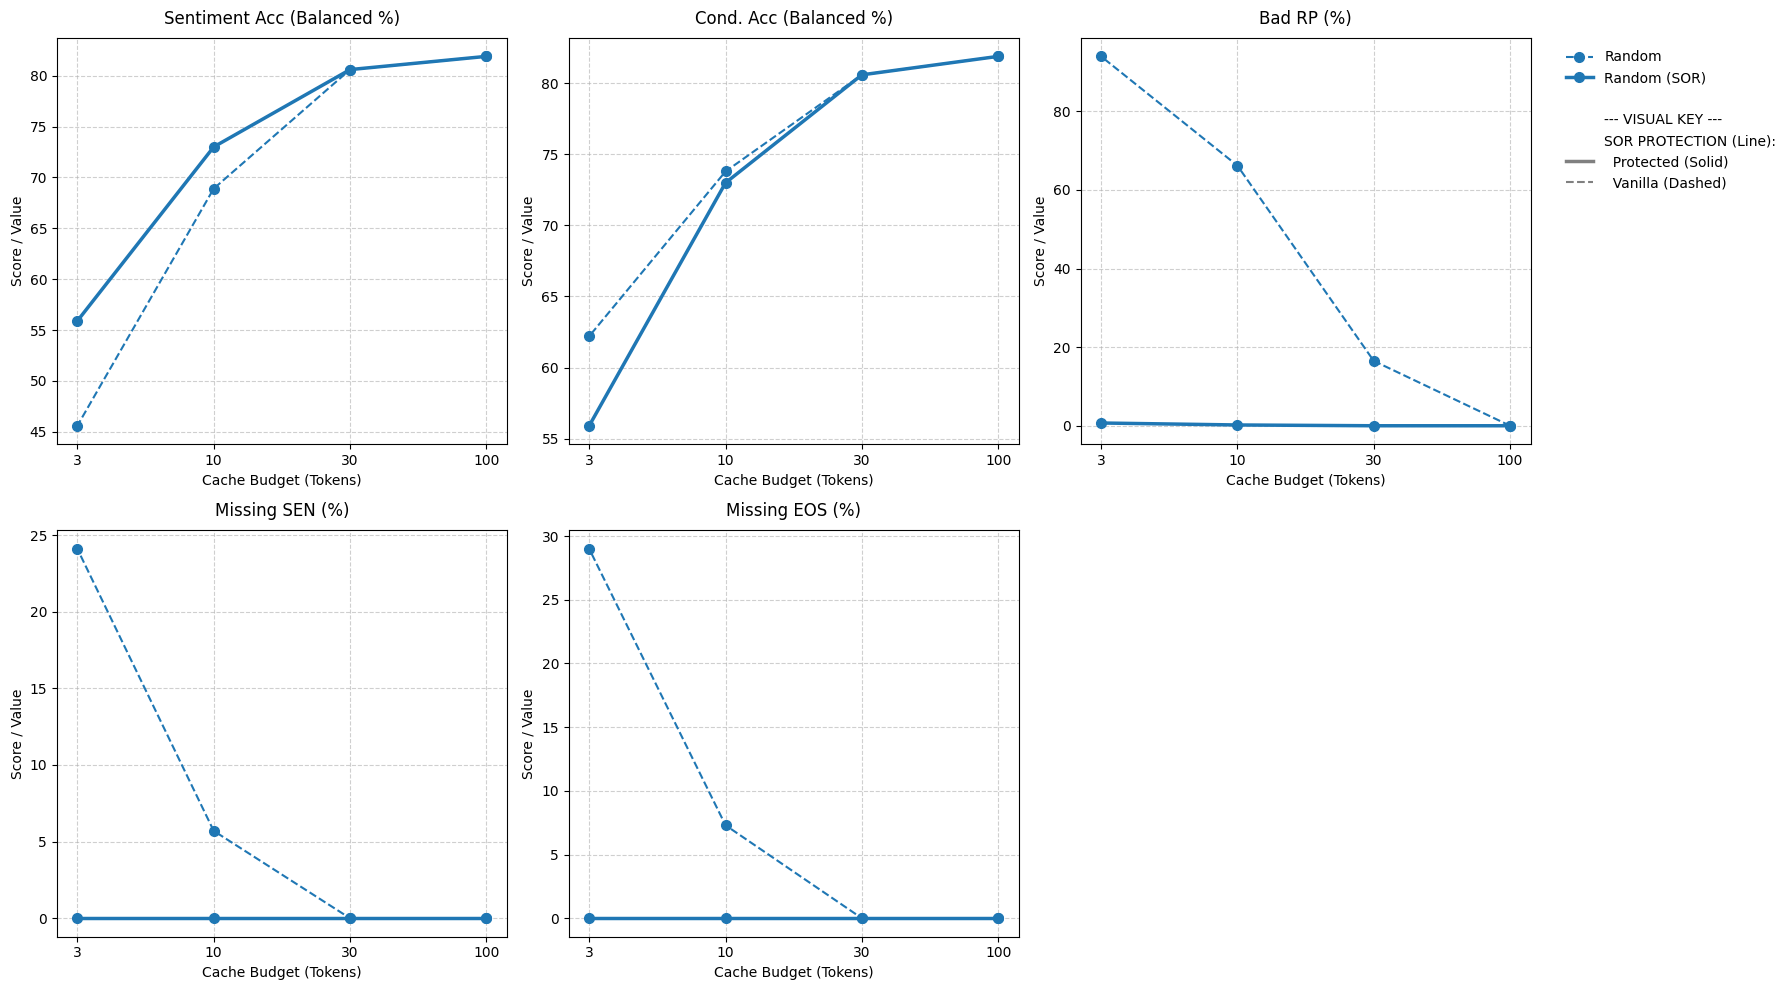

In [2]:
from src.benchmark_compression import plot_compression_benchmarks

plot_compression_benchmarks(
    {"Random": bench_rand,
    'Random (SOR)': bench_rand_ps}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP", "Missing SEN", "Missing EOS"], 
    use_balanced=True)

The results strongly validate our hypothesis. By simply preserving the `[SOR]` token, the "Bad RP Count" plummets from 94.0% down to a mere 0.7% at the lowest budget, and the occurrences of missing `[SEN]` and `[EOS]` tokens simultaneously drop to negligible levels. The model almost completely regains its structural formatting capabilities. 

When analyzing the performance, it is important to consider the inherent handicap introduced by this protection. For a budget of 3, two of the three available slots are now exclusively reserved for structural tokens (`[SOS]` and `[SOR]`). This leaves only a single slot for a randomly sampled word from the actual movie review. This semantic handicap is particularly evident with a budget of 3, where the conditional balanced accuracy dropped from 62.2% (in the unprotected baseline) to 55.9%. When the model successfully outputs a formatted answer, having only one random semantic word instead of two makes the classification tangibly harder. Nevertheless, the restored ability of the model to reliably construct a structured answer resulted in a significantly higher overall sentiment balanced accuracy across all lower budgets.

#### 2.1.3. **Compression During Autoregression**

Typically, KV cache compression is applied exclusively during the initial prefill phase. However, to maintain a strictly bounded (virtual) memory footprint, we extend this compression into the autoregressive generation phase. 

To achieve this efficiently without slowing down inference, we implemented a greedy eviction mechanism. Once the cache pointer reaches the maximum budget, the compressor activates for every subsequent generated token. It randomly selects a single token from the active cache to evict, explicitly protecting our structural anchors (`[SOS]` and `[SOR]`), and overwrites it with the newly generated token. 

This continuous eviction introduces an even more severe semantic handicap. A correctly formatted output requires generating 15 reasoning (`[RP]`) tokens and one sentiment (`[SEN]`) token (before the classification). Because these 16 generated tokens count toward the total budget, they actively cannibalize the context window. At a budget of 30, subtracting the 16 generated tokens and the 2 protected structural anchors leaves only 12 slots for the actual movie review. At a budget of 10, the model's own reasoning process will completely overwrite the original prompt (review text) before it even reaches the final classification step. 

The following benchmark evaluates the random baseline under this continuous eviction constraint:

In [25]:
experiment_configs = [
        {"budget": k, 'protect_sor':True, 'apply_on_decode': True} 
        for k in [100, 30, 10, 3]
    ]
bench_rand_ps_dec = run_compression_benchmark(RandomCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100, 'protect_sor': True, 'apply_on_decode': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[2/4] Benchmarking Config: {'budget': 30, 'protect_sor': True, 'apply_on_decode': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[3/4] Benchmarking Config: {'budget': 10, 'protect_sor': True, 'apply_on_decode': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[4/4] Benchmarking Config: {'budget': 3, 'protect_sor': True, 'apply_on_decode': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


COMPRESSION BENCHMARK SUMMARY
          Method  budget protect_sor apply_on_decode Sentiment Acc (%) Cond. Acc (%)     Missing EOS     Missing SEN    Bad RP Count
RandomCompressor     100           ✓               ✓       83.4 (81.9)   83.4 (81.9)       41 (0.0%)       41 (0.0%)       41 (0.0%)
RandomCompressor      30           ✓               ✓       10.3 (10.2)   86.4 (85.4)   93768 (88.1%)   93768 (88.1%)   93768 (88.1%)
RandomCompressor      10           ✓               ✓         0.0 (0.0)     nan (0.0) 106415 (100.0%) 106415 (100.0%) 106415 (100.0%)
RandomCompressor       3           ✓               ✓         0.0 (0.0)     nan (0.0) 106415 (100.0%) 106415 (100.0%) 106415 (100.0%)


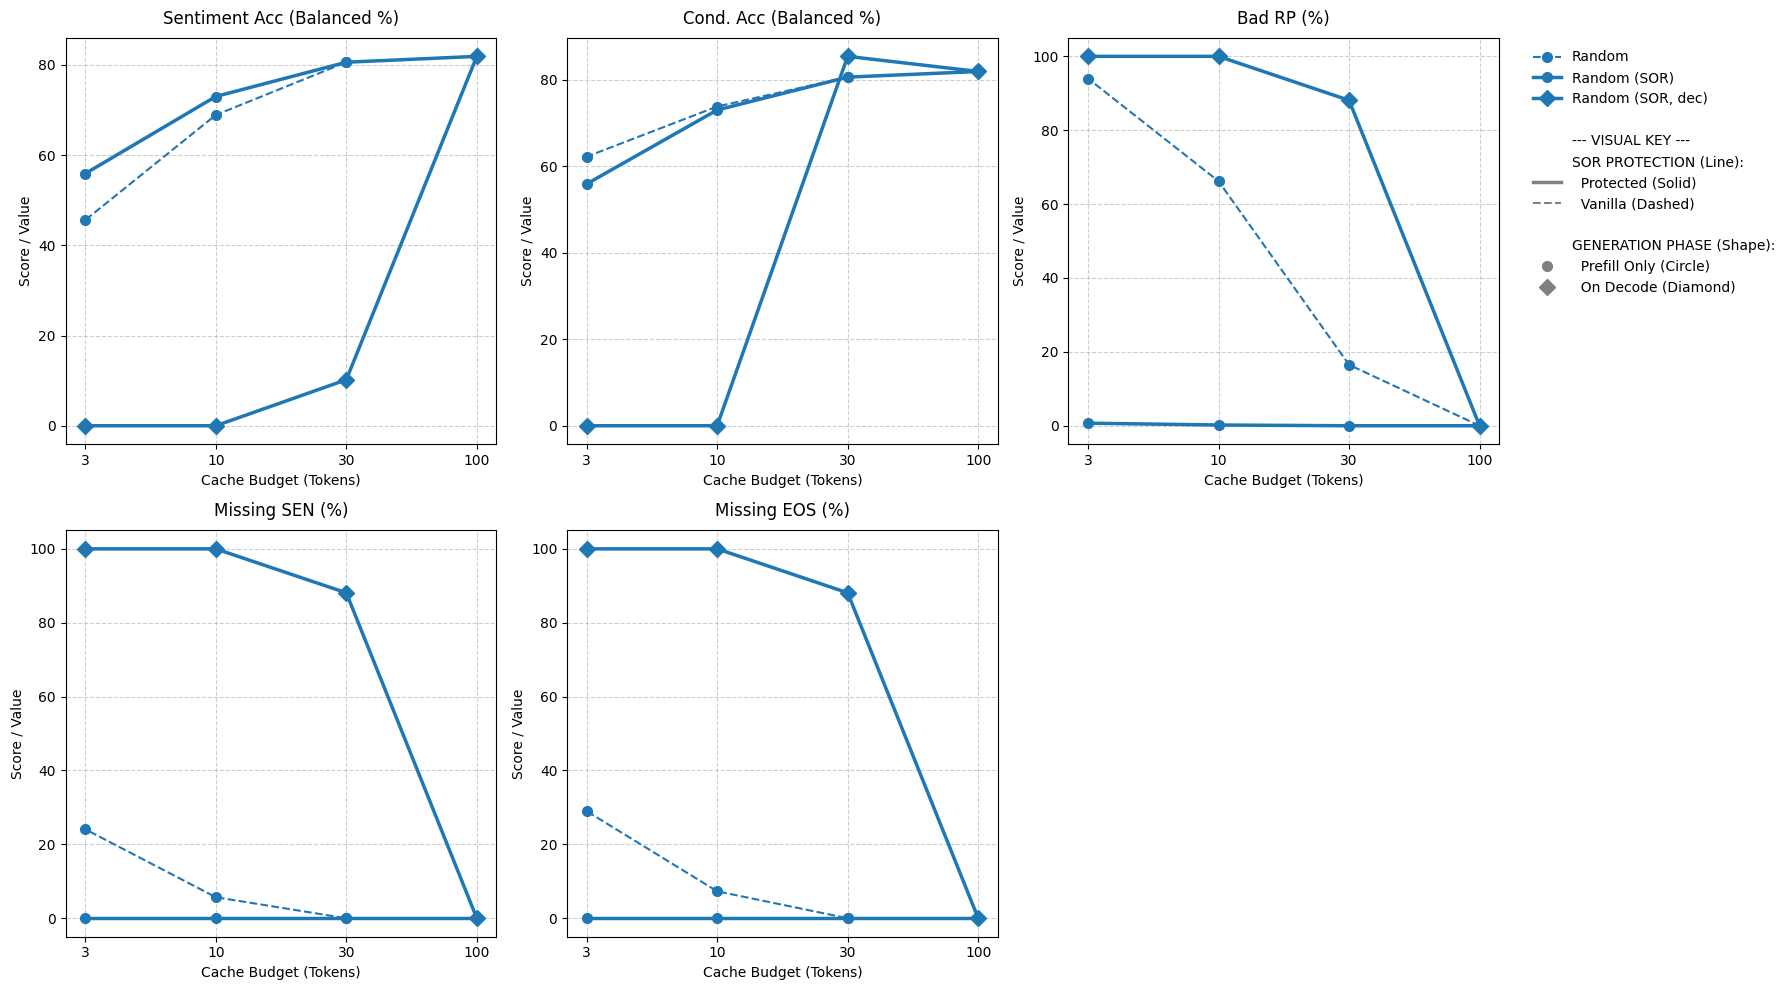

In [38]:
plot_compression_benchmarks(
    {"Random": bench_rand,
    'Random (SOR)': bench_rand_ps,
    "Random (SOR, dec)": bench_rand_ps_dec}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP", "Missing SEN", "Missing EOS"], 
    use_balanced=True)

At a budget of 100, the performance remains virtually unchanged from the prefill-only baseline. This is expected: 100 slots provide enough capacity to comfortably hold the compressed prompt alongside the 16 newly generated tokens, meaning the decode eviction bouncer is rarely triggered.

The breakdown occurs at a budget of 30. Theoretically, this budget should yield performance similar to the prefill-only budget of 10 (30 total slots minus 16 generated tokens minus 2 protected anchors leaves roughly 12 slots for the prompt). However, the formatting fails catastrophically, with an 88.1% Bad RP Count, and the number of missing `[SEN]` tokens skyrockets as a direct consequence. This failure is mechanically self-inflicted: as the model generates its reasoning sequence, the newly generated `[RP]` tokens randomly evict the older, previously generated `[RP]` tokens. This high collision rate destroys the model's internal token-counting mechanism, preventing it from reaching the required 15-token threshold to trigger a valid sentiment output. Interestingly, in the rare 11.9% of cases where the reasoning chain survives this self-cannibalization, the conditional balanced accuracy is remarkably high (85.4%).

For lower budgets (10 and 3), the model completely collapses to 0.0% accuracy. The required output formatting (16 tokens) strictly exceeds the physical memory constraints of the cache. Even though the `[SOR]` trigger is mathematically protected by the decode bouncer throughout the entire generation process, the model simply does not have enough slots to hold its own reasoning chain, resulting in 100% malformed answers.

### 2.2. **KNorm**

In [19]:
from src.compression import KNormCompressor

With a clear understanding of the mechanical baseline and the structural bottlenecks of the cache, we can now introduce our first heuristic driven approach: the KNorm compressor. 

Unlike the random baseline, KNorm operates on the hypothesis that the geometric magnitude of a token's Key vector inherently signals its importance to the attention mechanism. Specifically, this method calculates the $L_2$ norm of the Key vectors across the feature dimension $D$. For a given token at position $i$, the model averages this norm across all $H$ attention heads:

$$ \text{Norm}_i = \frac{1}{H} \sum_{h=1}^{H} \sqrt{\sum_{d=1}^{D} (k_{i, d}^{(h)})^2} $$



The compressor then ranks the tokens and retains the ones with the *lowest* average norms, assuming these specific vectors act as fundamental, stable anchors for the attention distribution. 

To properly evaluate this method, we will follow the exact same testing progression we used for the random baseline. The following benchmark applies KNorm exclusively during the prefill phase and explicitly disables our `[SOR]` protection trick. This will reveal whether the $L_2$ norm heuristic naturally recognizes the structural importance of the reasoning anchor, or if it suffers from the same catastrophic formatting collapse as the random baseline at lower budgets.

In [ ]:
experiment_configs = [
        {"budget": k, 'protect_sor':False, 'apply_on_decode': False} 
        for k in [100, 30, 10, 3]
    ]
bench_knorm = run_compression_benchmark(KNormCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100, 'protect_sor': False, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[2/4] Benchmarking Config: {'budget': 30, 'protect_sor': False, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[3/4] Benchmarking Config: {'budget': 10, 'protect_sor': False, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[4/4] Benchmarking Config: {'budget': 3, 'protect_sor': False, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


COMPRESSION BENCHMARK SUMMARY
         Method  budget protect_sor apply_on_decode Sentiment Acc (%) Cond. Acc (%) Missing EOS Missing SEN    Bad RP Count
KNormCompressor     100                                   83.4 (81.9)   83.4 (81.9)    1 (0.0%)    1 (0.0%)        3 (0.0%)
KNormCompressor      30                                   80.5 (78.6)   80.6 (78.6)  117 (0.1%)   78 (0.1%)   60246 (56.6%)
KNormCompressor      10                                   71.8 (68.9)   73.3 (70.5) 2646 (2.5%) 1839 (1.7%)  102641 (96.5%)
KNormCompressor       3                                   61.3 (56.5)   65.8 (60.6) 8220 (7.7%) 6174 (5.8%) 106398 (100.0%)


#### 2.2.1. **Comparison with the Random Compressor**

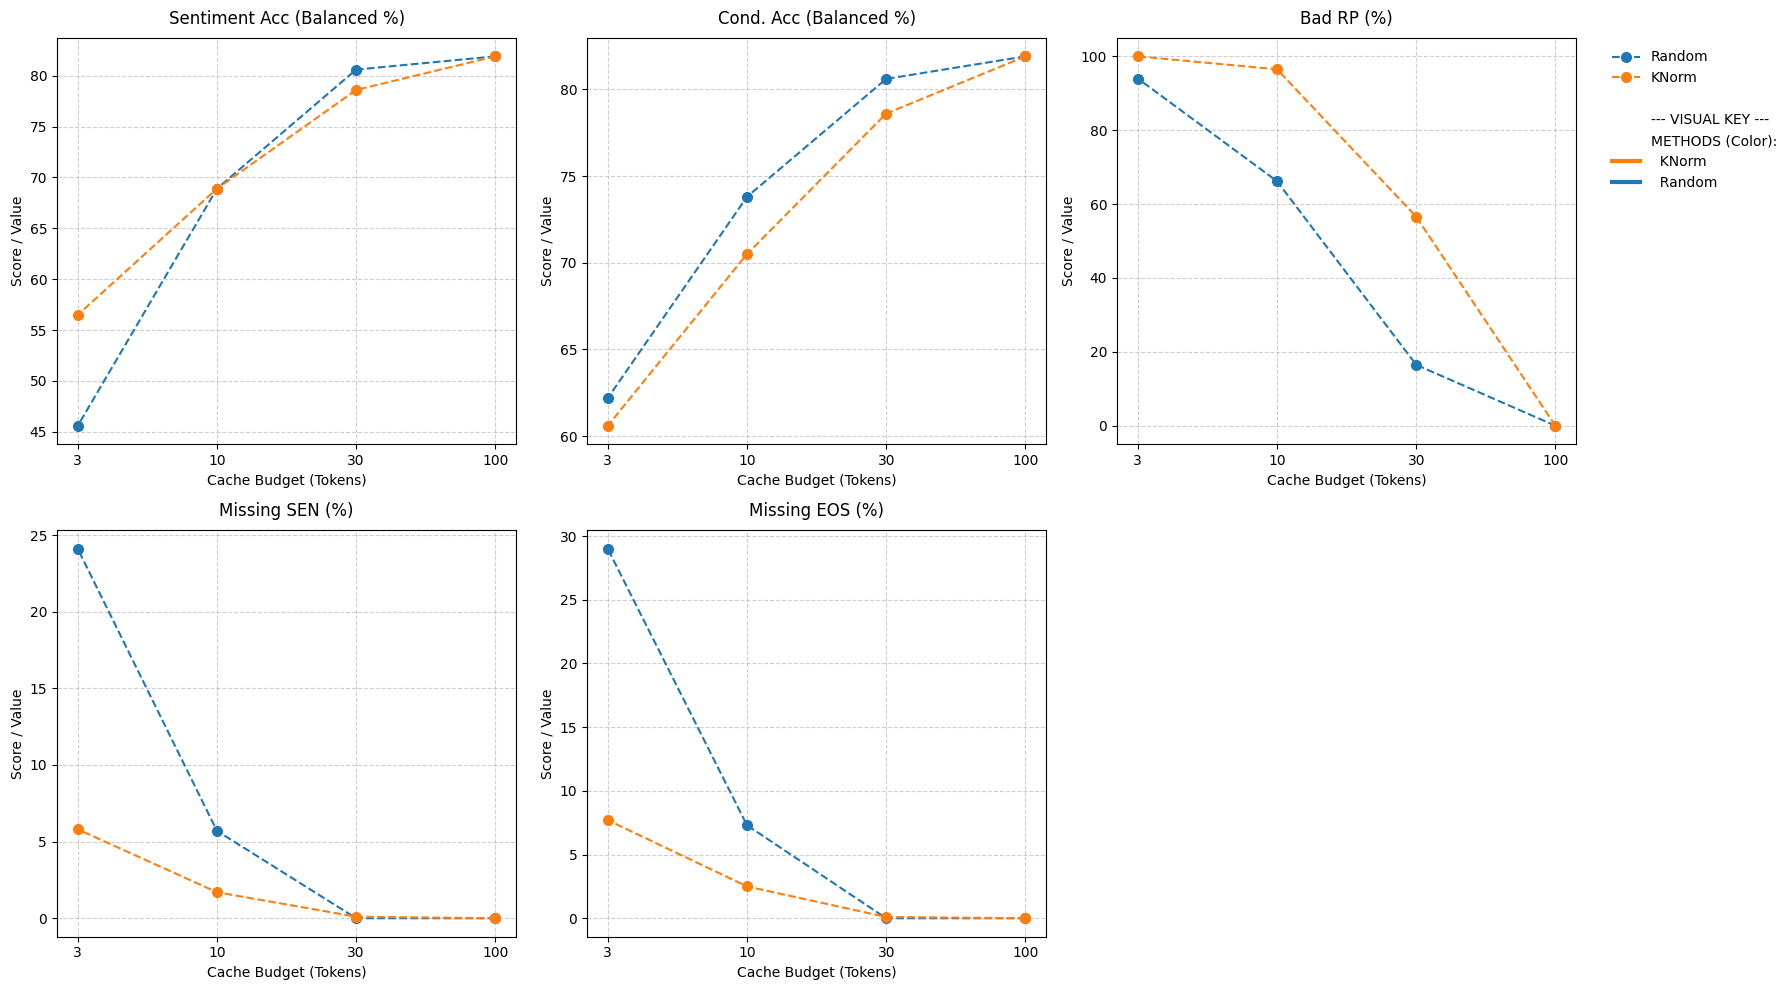

In [28]:
plot_compression_benchmarks(
    {"Random": bench_rand,
    'KNorm': bench_knorm}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP", "Missing SEN", "Missing EOS"], 
    use_balanced=True)

When we compare these results against our random baseline, a highly specific dynamic emerges. At a budget of 100, both methods perform identically well, which is expected since the cache is large enough to hold almost the entire prompt. However, as we reduce the budget to 30 and 10, KNorm exhibits a severe degradation in its ability to track reasoning tokens, resulting in a much higher Bad RP count than its Random counterpart. Furthermore, looking at the conditional balanced accuracy, which isolates pure semantic extraction, the random baseline dominates KNorm across all budgets.

Despite this semantic and structural handicap, a paradox appears at the extreme budget of 3. While KNorm's formatting completely collapses (hitting a 100% Bad RP count compared to Random's 94.0%), its overall unconditional balanced accuracy remains much better than a literal flip of a coin (56.5%). In contrast, the Random compressor completely collapses in its overall accuracy (45.6%).

This performance gap is directly explained by the `Missing SEN` and `Missing EOS` metrics. At a budget of 3, the KNorm compressor has entirely lost its ability to track the reasoning token constraint. However, it still successfully outputs a sentiment token in 94.2% of cases (only a 5.8% Missing SEN rate). The Random baseline, on the other hand, frequently gets completely lost during generation, failing to output any sentiment at all in 24.1% of cases. 

Because KNorm manages to survive the generation loop and output a valid sentiment more often, its overall balanced accuracy remains artificially inflated. However, if we look strictly at conditional accuracy, which evaluates the semantic correctness only when a valid sentiment is actually produced, the random baseline remains superior (e.g., 62.2% versus 60.6% at a budget of 3). This proves that KNorm's apparent superiority at the lowest budget is not due to a better semantic understanding of the prompt, but simply its mechanical ability to avoid crashing during the generation phase.

#### 2.2.2 **KNorm `SOR` Protected**

In [ ]:
experiment_configs = [
        {"budget": k, 'protect_sor':True, 'apply_on_decode': False} 
        for k in [100, 30, 10, 3]
    ]
bench_knorm_ps = run_compression_benchmark(KNormCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100, 'protect_sor': True, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[2/4] Benchmarking Config: {'budget': 30, 'protect_sor': True, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[3/4] Benchmarking Config: {'budget': 10, 'protect_sor': True, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[4/4] Benchmarking Config: {'budget': 3, 'protect_sor': True, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


COMPRESSION BENCHMARK SUMMARY
         Method  budget protect_sor apply_on_decode Sentiment Acc (%) Cond. Acc (%) Missing EOS Missing SEN Bad RP Count
KNormCompressor     100           ✓                       83.4 (81.9)   83.4 (81.9)    1 (0.0%)    1 (0.0%)     2 (0.0%)
KNormCompressor      30           ✓                       80.7 (78.7)   80.7 (78.7)    0 (0.0%)    0 (0.0%)    16 (0.0%)
KNormCompressor      10           ✓                       73.6 (69.0)   73.6 (69.0)    0 (0.0%)    0 (0.0%)   105 (0.1%)
KNormCompressor       3           ✓                       66.6 (55.1)   66.6 (55.1)    0 (0.0%)    0 (0.0%)   479 (0.5%)


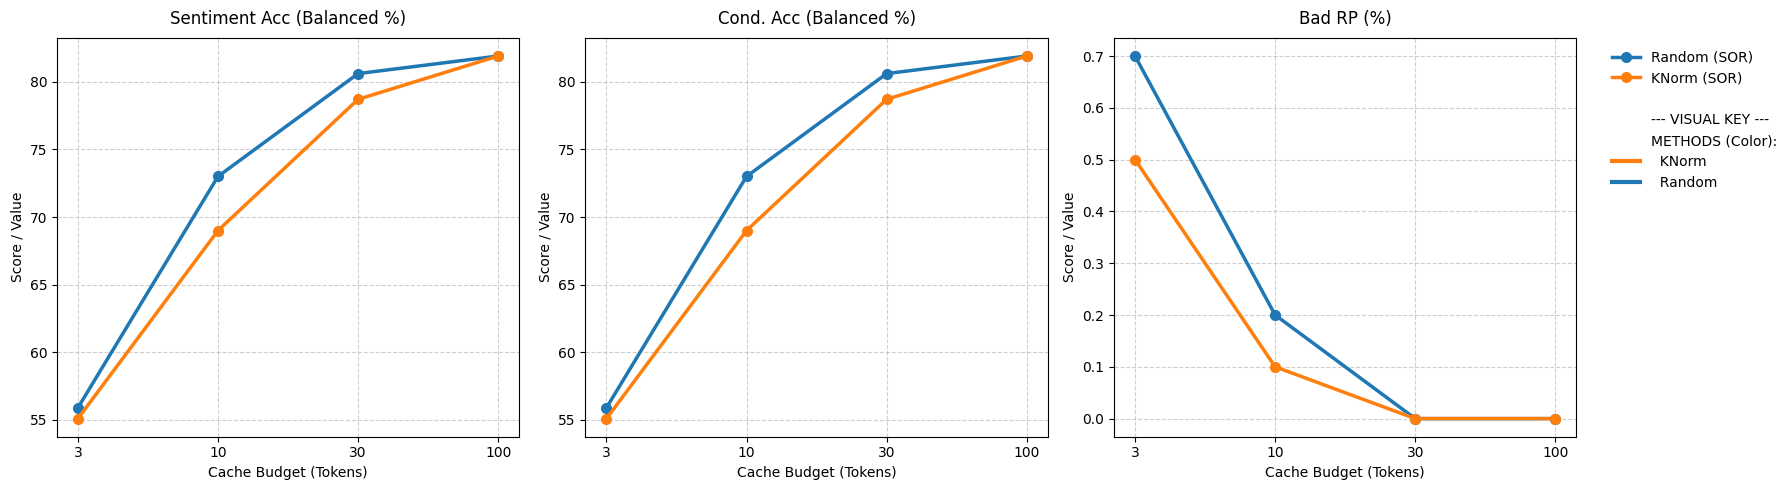

In [34]:
plot_compression_benchmarks(
    {"Random (SOR)": bench_rand_ps,
    'KNorm (SOR)': bench_knorm_ps}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP"], 
    use_balanced=True)

When we enforce the protection of the `[SOR]` token, the formatting failures plummet just as they did with the random baseline. A notable side effect of this structural rescue is that the overall balanced accuracy and the conditional balanced accuracy become virtually identical in our plots. Because the protected model almost never fails to output a final sentiment token, it is no longer penalized for structural crashes. Consequently, the overall accuracy metric becomes a direct reflection of the model's true semantic performance.

Comparing the protected KNorm against the protected Random Compressor reveals an interesting dynamic. The random baseline maintains a slight edge in overall classification performance. For example, at a budget of 10, Random achieves a 73.0% balanced accuracy compared to KNorm's 69.0%. Conversely, KNorm achieves a marginally better Bad RP count across the lower budgets, recording 479 formatting failures at a budget of 3 compared to Random's 749.

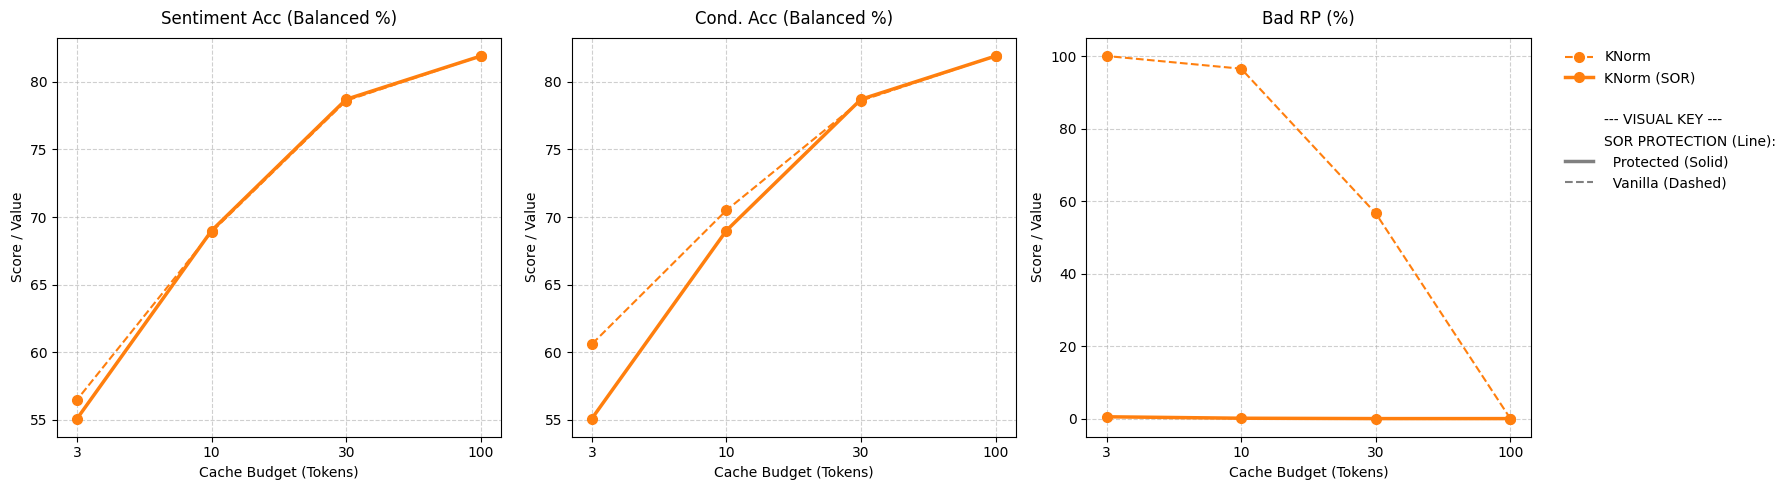

In [36]:
plot_compression_benchmarks(
    {'KNorm': bench_knorm,
    'KNorm (SOR)': bench_knorm_ps}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP"], 
    use_balanced=True)

Comparing the protected KNorm against its unprotected counterpart highlights a different dynamic than the random baseline. While protecting the `[SOR]` token successfully resolves the reasoning format failure, the overall classification performance does not experience the same dramatic leap. In fact, at the extreme budget of 3, the unprotected KNorm actually slightly outperforms the protected version in balanced accuracy.

This happens because protecting the `[SOR]` token introduces the exact same semantic token handicap we saw in the baseline, reserving two of the three available slots purely for structure and causing a drop in conditional accuracy. However, since the unprotected KNorm already maintained a relatively strong ability to output a final sentiment token on its own, this structural rescue does not artificially inflate the overall accuracy enough to offset that semantic handicap.

#### 2.2.3 **KNorm on Autoregression**

In [ ]:
experiment_configs = [
        {"budget": k, 'protect_sor':True, 'apply_on_decode': True} 
        for k in [100, 30, 10, 3]
    ]
bench_knorm_ps_dec = run_compression_benchmark(KNormCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100, 'protect_sor': True, 'apply_on_decode': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[2/4] Benchmarking Config: {'budget': 30, 'protect_sor': True, 'apply_on_decode': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[3/4] Benchmarking Config: {'budget': 10, 'protect_sor': True, 'apply_on_decode': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[4/4] Benchmarking Config: {'budget': 3, 'protect_sor': True, 'apply_on_decode': True}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


COMPRESSION BENCHMARK SUMMARY
         Method  budget protect_sor apply_on_decode Sentiment Acc (%) Cond. Acc (%)     Missing EOS     Missing SEN    Bad RP Count
KNormCompressor     100           ✓               ✓       83.4 (81.9)   83.4 (81.9)        8 (0.0%)        8 (0.0%)       41 (0.0%)
KNormCompressor      30           ✓               ✓       14.0 (13.8)   82.9 (81.0)   89360 (84.0%)   87666 (82.4%)   93765 (88.1%)
KNormCompressor      10           ✓               ✓         0.0 (0.0)     nan (0.0) 106415 (100.0%) 106415 (100.0%) 106415 (100.0%)
KNormCompressor       3           ✓               ✓         0.0 (0.0)     nan (0.0) 106415 (100.0%) 106415 (100.0%) 106415 (100.0%)


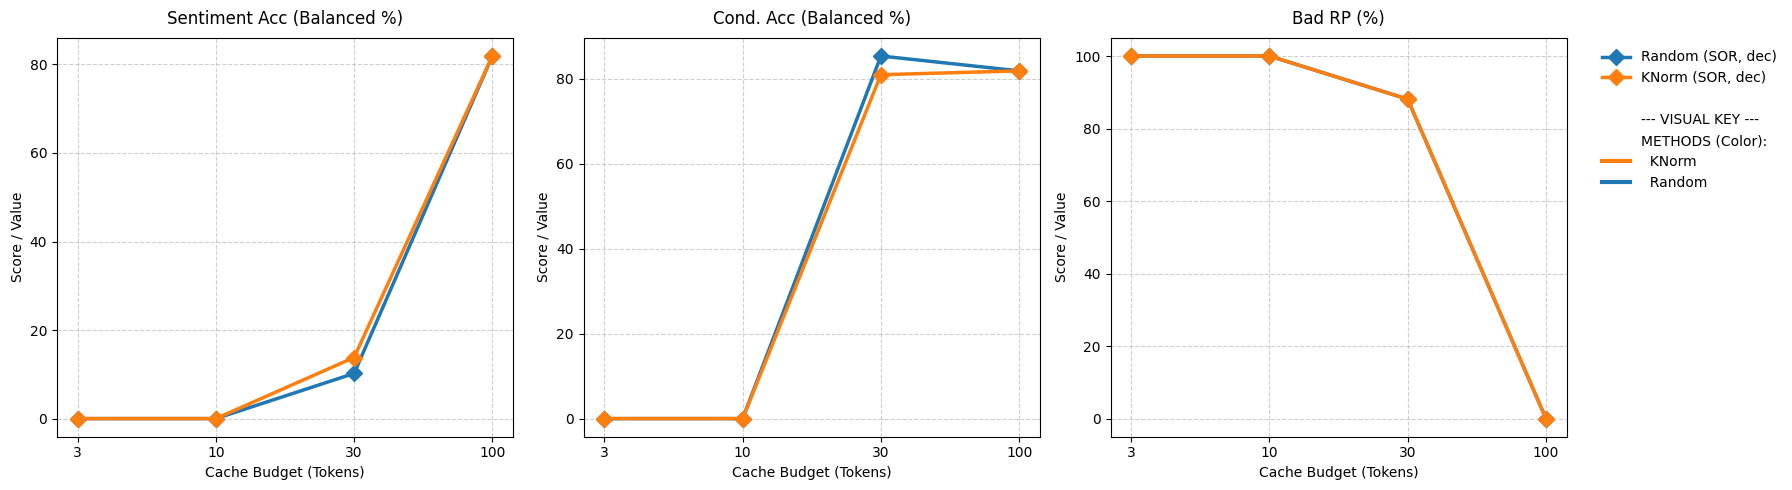

In [42]:
plot_compression_benchmarks(
    {"Random (SOR, dec)": bench_rand_ps_dec,
    'KNorm (SOR, dec)': bench_knorm_ps_dec}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP"], 
    use_balanced=True)

Running the compression continuously into the autoregression phase of generation, we see basically the same signature as with the Random compressor: a severe performance degradation even at a generous budget of 30.

### 2.3. **SnapKV**

Having explored the KNorm heuristic, which identifies fundamental structural anchors based on their intrinsic vector magnitude, we now examine an alternative approach: SnapKV. 

Instead of relying on the geometric properties of the Key vectors themselves, SnapKV leverages the explicit attention distribution to decide what to keep. The core hypothesis is that the tokens most heavily attended to by the end of the prompt are the ones most critical for the subsequent generation phase. 

In our specific implementation, SnapKV isolates the Query vector of the final token in the sequence (`[SOR]`) and calculates its raw attention scores against every preceding Key vector in the cache. The model then averages these scores across all $H$ attention heads to get a single importance score for each position $i$:

$$\text{Score}_i = \frac{1}{H} \sum_{h=1}^{H} \left( \sum_{d=1}^{D} q_{\text{fin}, d}^{(h)} \cdot k_{i, d}^{(h)} \right)$$

The compressor then ranks the cache and retains the tokens with the *highest* attention scores. 

*Note: The standard SnapKV formulation applies a softmax operation over these attention scores before pooling. Our implementation utilizes the raw, pre-softmax attention logits. While this deviation was initially an oversight, subsequent empirical testing revealed that applying the strict softmax operation actually resulted in slightly lower classification performance in some cases. Therefore, we elected to retain this pre-softmax variant for our final analysis.* 

To evaluate how well this attention-driven heuristic performs, we will start with our standard naive configuration. The following benchmark applies SnapKV exclusively during the prefill phase and explicitly disables the `[SOR]` protection trick. This will test whether the model's own attention mechanism naturally recognizes the importance of the reasoning anchor and preserves it, or if it falls into the same traps as our previous methods.

In [2]:
from src.compression import SnapKVCompressor

In [ ]:
experiment_configs = [
        {"budget": k, 'protect_sor':False, 'apply_on_decode': False} 
        for k in [100, 30, 10, 3]
    ]
bench_snapkv = run_compression_benchmark(SnapKVCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100, 'protect_sor': False, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[2/4] Benchmarking Config: {'budget': 30, 'protect_sor': False, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[3/4] Benchmarking Config: {'budget': 10, 'protect_sor': False, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[4/4] Benchmarking Config: {'budget': 3, 'protect_sor': False, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


COMPRESSION BENCHMARK SUMMARY
          Method  budget protect_sor apply_on_decode Sentiment Acc (%) Cond. Acc (%) Missing EOS Missing SEN   Bad RP Count
SnapKVCompressor     100                                   83.4 (81.9)   83.4 (81.9)    0 (0.0%)    0 (0.0%)       1 (0.0%)
SnapKVCompressor      30                                   81.7 (80.5)   81.7 (80.5)    0 (0.0%)    0 (0.0%)    8653 (8.1%)
SnapKVCompressor      10                                   72.1 (73.1)   72.1 (73.1)    2 (0.0%)    1 (0.0%)  93902 (88.2%)
SnapKVCompressor       3                                   54.7 (61.2)   54.8 (61.3)  140 (0.1%)  115 (0.1%) 105741 (99.4%)


### 2.3.1 **Final Vanilla Comparison**

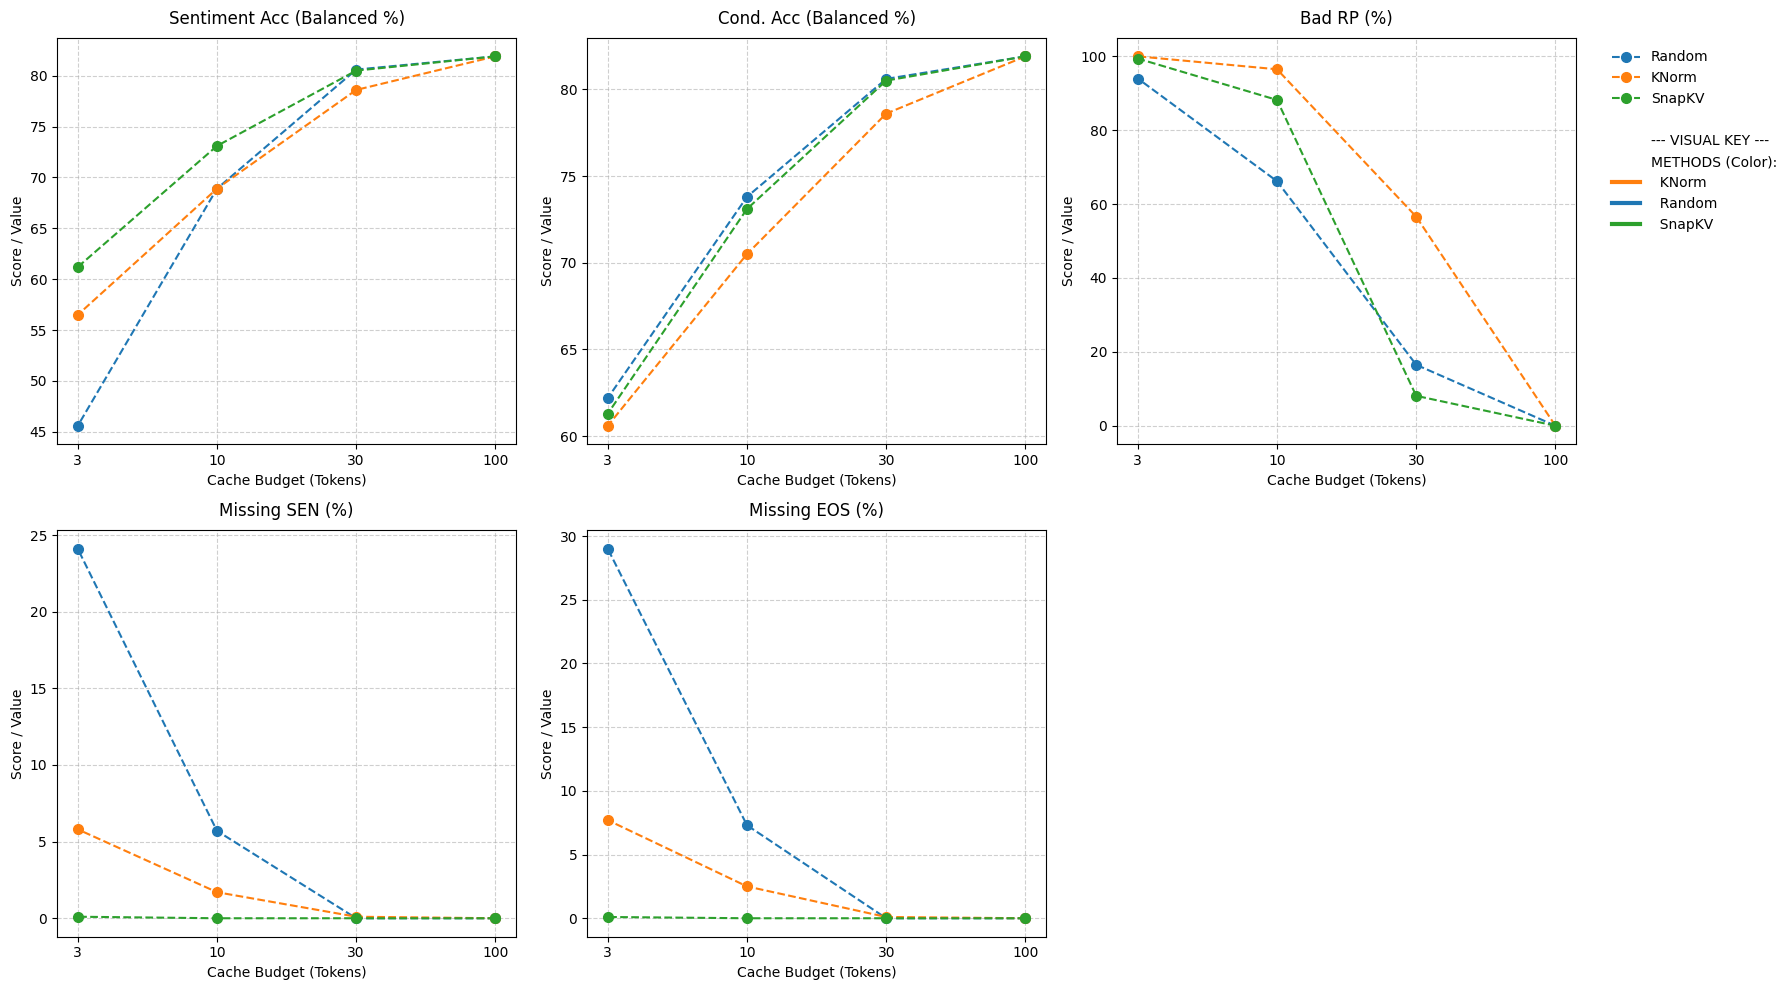

In [43]:
plot_compression_benchmarks(
    {"Random": bench_rand,
    'KNorm': bench_knorm, 
    'SnapKV': bench_snapkv}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP", "Missing SEN", "Missing EOS"], 
    use_balanced=True)

Looking at the naive implementations across all three methods, SnapKV shows some strong advantages. Most impressively, even without explicit protection, it natively maintains an almost negligible rate of missing `[SEN]` and `[EOS]` tokens across all budgets. This indicates that its attention mechanism inherently understands the need to complete the generation sequence. While its Bad RP count at the lowest budgets remains high and roughly on par with the other methods, at a generous budget of 30, SnapKV actually achieves a lower Bad RP count than the random baseline. Furthermore, in terms of conditional balanced accuracy, SnapKV performs on par with the random baseline, and it noticeably outperforms KNorm overall by consistently producing fewer malformed sequences.

### 2.3.2 **SnapKV `SOR` Protected**

In [ ]:
experiment_configs = [
        {"budget": k, 'protect_sor':True, 'apply_on_decode': False} 
        for k in [100, 30, 10, 3]
    ]
bench_snapkv_ps = run_compression_benchmark(SnapKVCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100, 'protect_sor': True, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[2/4] Benchmarking Config: {'budget': 30, 'protect_sor': True, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[3/4] Benchmarking Config: {'budget': 10, 'protect_sor': True, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


[4/4] Benchmarking Config: {'budget': 3, 'protect_sor': True, 'apply_on_decode': False}


Inferring Batches:   0%|          | 0/416 [00:00<?, ?it/s]


COMPRESSION BENCHMARK SUMMARY
          Method  budget protect_sor apply_on_decode Sentiment Acc (%) Cond. Acc (%) Missing EOS Missing SEN Bad RP Count
SnapKVCompressor     100           ✓                       83.4 (81.9)   83.4 (81.9)    0 (0.0%)    0 (0.0%)     1 (0.0%)
SnapKVCompressor      30           ✓                       81.9 (80.6)   81.9 (80.6)    0 (0.0%)    0 (0.0%)     2 (0.0%)
SnapKVCompressor      10           ✓                       74.3 (72.3)   74.3 (72.3)    0 (0.0%)    0 (0.0%)    15 (0.0%)
SnapKVCompressor       3           ✓                       65.6 (52.9)   65.6 (52.9)    0 (0.0%)    0 (0.0%)   260 (0.2%)


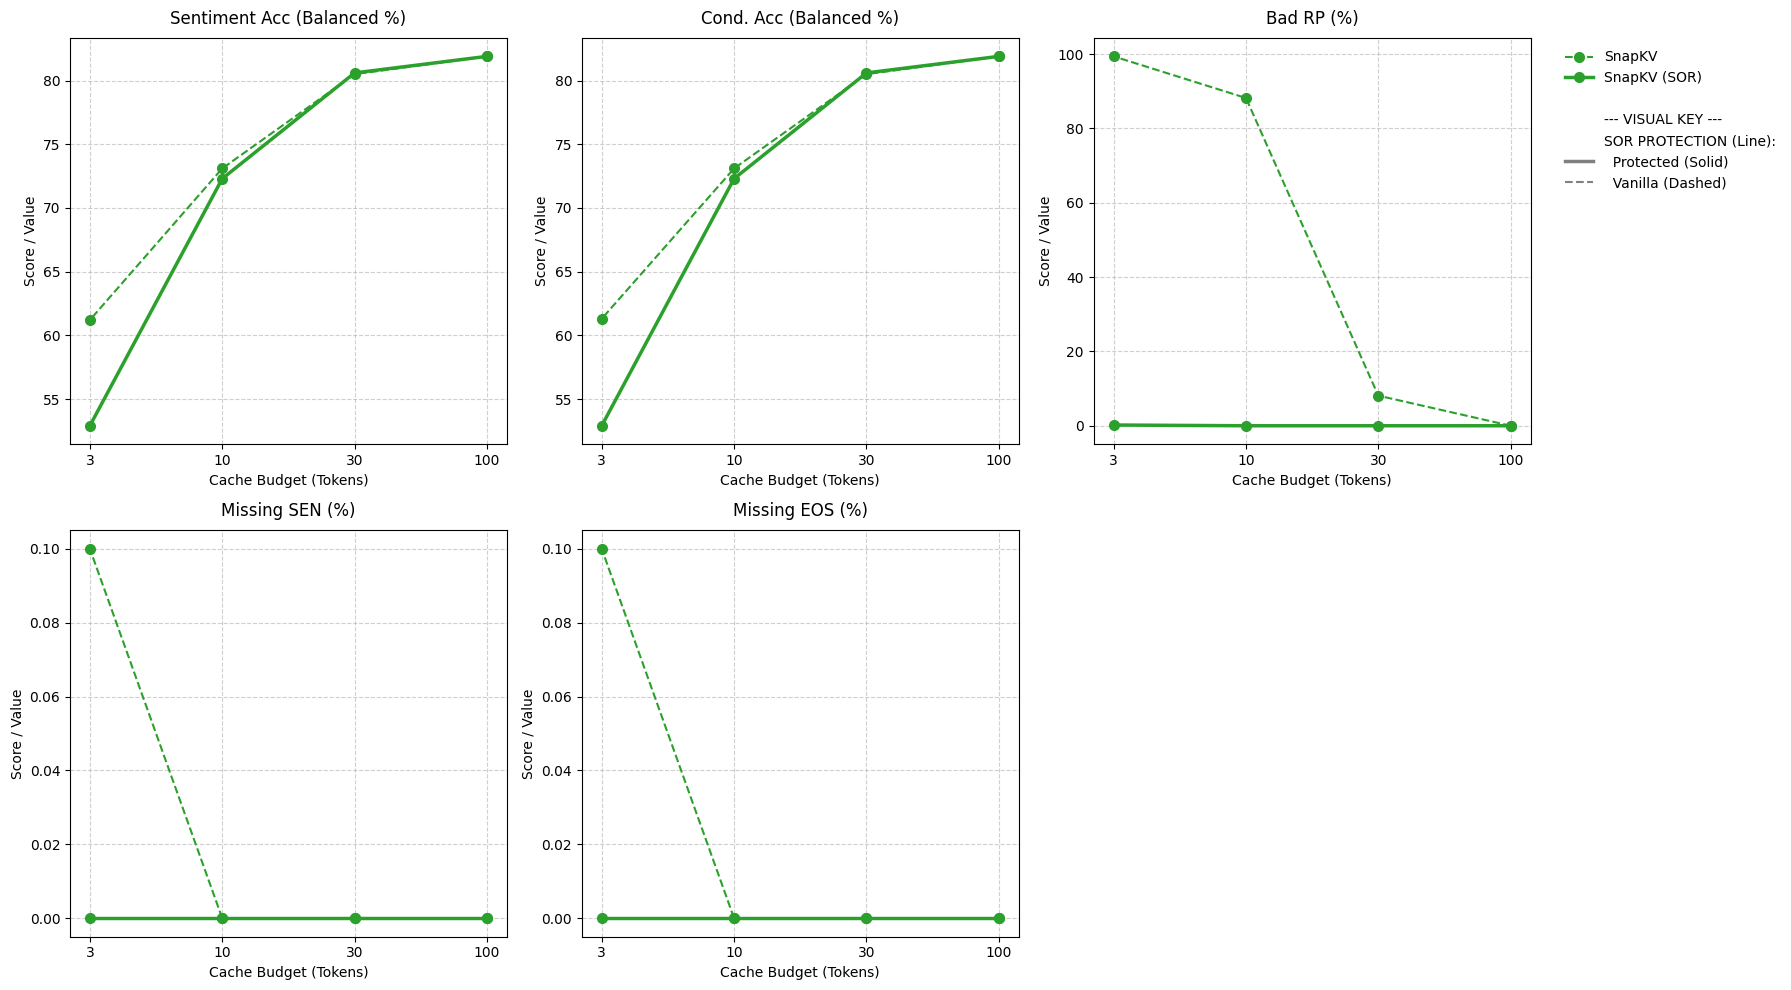

In [49]:
plot_compression_benchmarks(
    {'SnapKV': bench_snapkv,
    'SnapKV (SOR)': bench_snapkv_ps}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP", "Missing SEN", "Missing EOS"], 
    use_balanced=True)

As we observed with KNorm, enabling `[SOR]` protection for SnapKV results in a strict semantic token handicap. This penalty is even more pronounced here because the unprotected SnapKV already exhibited naturally excellent output structuring with almost zero missing `[SEN]` tokens. Consequently, forcing the cache to retain the structural anchors at an extreme budget of 3 actively depresses its classification power, causing the protected SnapKV to perform worse in overall balanced accuracy than its unprotected counterpart.

### 2.3.3 **Final `SOR` Protected Comparison**

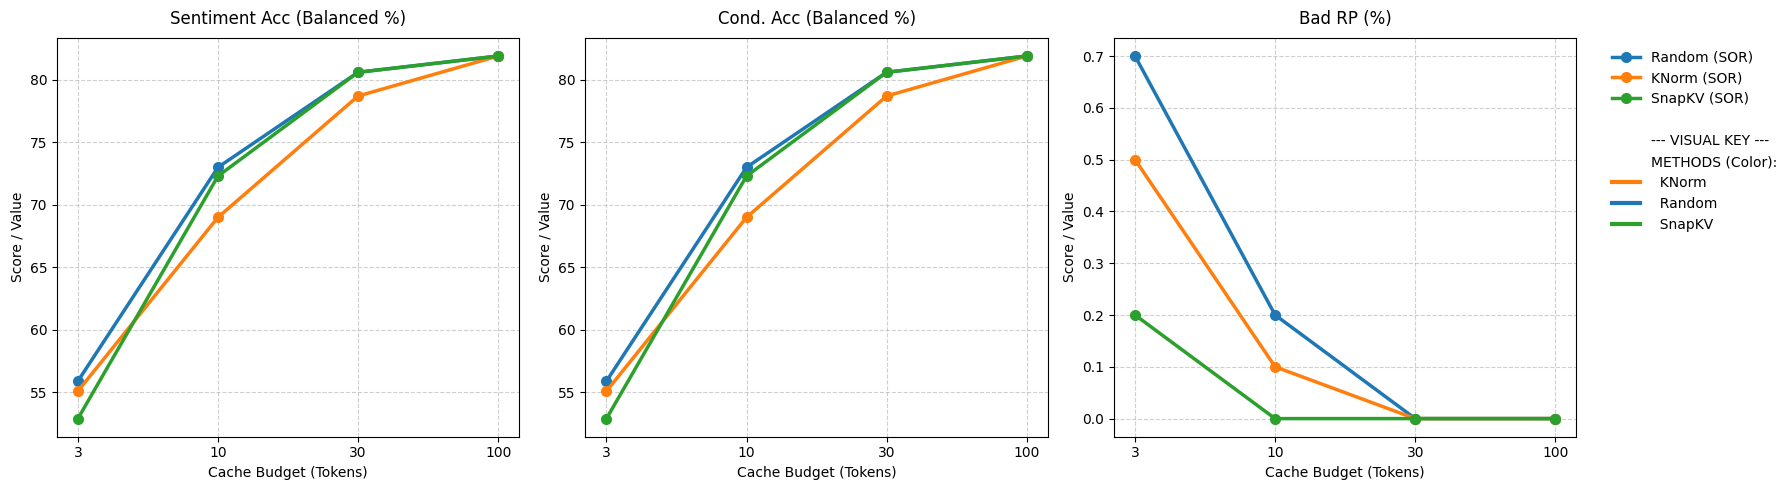

In [52]:
plot_compression_benchmarks(
    {"Random (SOR)": bench_rand_ps,
    'KNorm (SOR)': bench_knorm_ps, 
    'SnapKV (SOR)': bench_snapkv_ps}, 
    metrics=["Sentiment Acc", "Cond. Acc", "Bad RP"], 
    use_balanced=True)

Comparing the protected versions of all three methods reveals a consistent hierarchy. In terms of accuracy, the random baseline still slightly dominates both KNorm and SnapKV across all budgets, though the semantic performances of all three remain relatively close to one another. Where SnapKV truly distinguishes itself is in structural compliance. It achieves the best Bad RP metrics of any method tested so far, maintaining negligible formatting errors down to a budget of 10, and recording less than half the Bad RP count of KNorm at the extreme budget of 3.

### 2.3.4 **SnapKV on Decode**

In [4]:
experiment_configs = [
        {"budget": k, 'protect_sor':True, 'apply_on_decode': True} 
        for k in [100, 30, 10, 3]
    ]
bench_snapkv_ps_dec = run_compression_benchmark(SnapKVCompressor, experiment_configs)

Loading tokenizer...
Loading config and initialized model...
Model weights loaded from best_model_50.eqx.
Loaded 106415 test samples.

[1/4] Benchmarking Config: {'budget': 100, 'protect_sor': True, 'apply_on_decode': True}


ValueError: SnapKVCompressor only supports prefill compression. apply_on_decode must be False.

SnapKV is fundamentally designed as a prefill-based compression strategy. Its heuristic identifies important tokens by calculating the attention scores of the final prompt token against all preceding keys. Because this ranking is anchored to a specific fixed point in the sequence, our implementation does not support the `apply_on_decode` functionality.

While it is theoretically possible to adapt this method for decoding by dynamically updating attention scores at each step, we have already observed that continuous cache eviction during the autoregressive phase causes a catastrophic collapse in both the Random and KNorm baselines. Given that continuous compression appears to be fundamentally incompatible with our reasoning task, we will restrict our evaluation of SnapKV to the prefill-only phase.

### 2.4 **Cache Allocation Analysis: Structure vs. Semantics**

The evaluation of various KV cache compression strategies reveals an interesting interplay between memory efficiency, structural stability, and semantic performance. To better understand these dynamics, it is helpful to consider how the underlying model was optimized. The training was conducted entirely as a next-token prediction task across fully structured reviews. Consequently, every correctly predicted token carried the same weight in the loss function, whether it was a piece of the movie review, a step in the reasoning chain, or the final sentiment label. While this approach provided a strong signal for the model to learn the structural format of the output, it also meant that correctly classifying the sentiment was mathematically secondary to generating the correct sequence structure.

This training objective helps explain the counterintuitive performance of our baselines. Heuristics like KNorm and SnapKV are designed to extract the most relevant tokens for the task the model was trained to execute. Since the model learned to heavily penalize structural failures during training, we hypothesize that these heuristics naturally prioritize retaining the tokens necessary to keep the output format intact.

To investigate this, we can initially look at the raw tokens kept and evicted by the model.

In [1]:
from src.analyze_evictions import inspect_token_eviction

inspect_token_eviction(compressor_name="random", aggregation='sequence_any')

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Loading tokenizer and configuration...
Loading data...
Initializing model...
Metal device set to: Apple M4 Pro

systemMemory: 48.00 GB
maxCacheSize: 18.72 GB



W0000 00:00:1774177964.870759 9069229 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1774177964.880268 9069229 service.cc:145] XLA service 0x9ca2e5200 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774177964.880278 9069229 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1774177964.881333 9069229 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1774177964.881344 9069229 mps_client.cc:384] XLA backend will use up to 40200421376 bytes on device 0 for SimpleAllocator.


Loaded weights from best_model_50.eqx.


Inspecting RANDOM:   0%|          | 0/832 [00:00<?, ?it/s]


[RANDOM | Budget 18] TOP 5 MOST KEPT (Retention Rate)
| Rank | Token           | Retained  | Kept / Total    |
|------|-----------------|-----------|-----------------|
|    1 | [SOS]           |   100.00% | 106415 / 106415 |
|    2 | mindless        |   100.00% |       108 / 108 |
|    3 | steam           |   100.00% |       105 / 105 |
|    4 | fluff           |   100.00% |       105 / 105 |
|    5 | plaus           |   100.00% |         69 / 69 |

[RANDOM | Budget 18] TOP 5 MOST EVICTED (Retention Rate)
| Rank | Token           | Retained  | Kept / Total    |
|------|-----------------|-----------|-----------------|
|    1 | ã               |    77.94% |         53 / 68 |
|    2 | ç               |    82.35% |         70 / 85 |
|    3 | wife            |    84.44% |       114 / 135 |
|    4 | vide            |    86.15% |         56 / 65 |
|    5 | dio             |    86.36% |         57 / 66 |


In [2]:
from src.analyze_evictions import inspect_token_eviction

inspect_token_eviction(compressor_name="random", aggregation="sequence_all")

Loading tokenizer and configuration...
Loading data...
Initializing model...
Loaded weights from best_model_50.eqx.


Inspecting RANDOM:   0%|          | 0/832 [00:00<?, ?it/s]


[RANDOM | Budget 18] TOP 5 MOST KEPT (Retention Rate)
| Rank | Token           | Retained  | Kept / Total    |
|------|-----------------|-----------|-----------------|
|    1 | [SOS]           |   100.00% | 106415 / 106415 |
|    2 | forgettable     |    33.97% |        89 / 262 |
|    3 | teens           |    33.02% |        35 / 106 |
|    4 | strangely       |    31.97% |        47 / 147 |
|    5 | absorbing       |    30.73% |        55 / 179 |

[RANDOM | Budget 18] TOP 5 MOST EVICTED (Retention Rate)
| Rank | Token           | Retained  | Kept / Total    |
|------|-----------------|-----------|-----------------|
|    1 | ç               |     0.00% |          0 / 85 |
|    2 | enced           |     0.00% |         0 / 115 |
|    3 | execut          |     0.00% |          0 / 64 |
|    4 | tting           |     0.00% |          0 / 79 |
|    5 | ã               |     0.00% |          0 / 68 |


In [60]:
from src.analyze_evictions import inspect_token_eviction

inspect_token_eviction(compressor_name="random")

Loading tokenizer and configuration...
Loading data...
Initializing model...
Loaded weights from best_model_50.eqx.


Inspecting RANDOM:   0%|          | 0/832 [00:00<?, ?it/s]


[RANDOM | Budget 18] TOP 5 MOST KEPT (Retention Rate)
| Rank | Token           | Retained  | Kept / Total    |
|------|-----------------|-----------|-----------------|
|    1 | [SOS]           |   100.00% | 638490 / 638490 |
|    2 | absorbing       |    68.81% |      739 / 1074 |
|    3 | strangely       |    67.35% |       594 / 882 |
|    4 | engrossing      |    65.79% |     1050 / 1596 |
|    5 | unfunny         |    65.63% |      697 / 1062 |

[RANDOM | Budget 18] TOP 5 MOST EVICTED (Retention Rate)
| Rank | Token           | Retained  | Kept / Total    |
|------|-----------------|-----------|-----------------|
|    1 | ã               |    24.02% |        98 / 408 |
|    2 | ê               |    28.16% |        49 / 174 |
|    3 | espe            |    28.21% |         22 / 78 |
|    4 | ç               |    28.43% |       145 / 510 |
|    5 | ultim           |    29.17% |         21 / 72 |


For instance, a manual inspection of the Random compressor at a low budget reveals that the critical structural anchor (`[SOR]` token) do not even appear among its top retained tokens. While inspecting these raw token lists can provide some helpful initial intuition, analyzing compression behavior this way is highly susceptible to confirmation bias and cherry-picking. To draw more objective conclusions, we need to define consistent, dataset-wide metrics to evaluate structural and semantic retention.

### 2.4.1. **Validating Structural Bias: The `[SOR]` Retention Test**
If heuristic compressors prioritize structure, they should natively protect structural anchors even without explicit programmatic intervention. To test this, we tracked the retention rate of the `[SOR]` token across our compression budgets:

In [63]:
from src.analyze_evictions import evaluate_sor_retention

evaluate_sor_retention();


Loading tokenizer and configuration...
Loading data...
Initializing model...
Loaded weights from best_model_50.eqx.

RUNNING [SOR] TOKEN RETENTION SWEEP


Eval RANDOM (B=3):   0%|          | 0/832 [00:00<?, ?it/s]

Eval RANDOM (B=10):   0%|          | 0/832 [00:00<?, ?it/s]

Eval RANDOM (B=30):   0%|          | 0/832 [00:00<?, ?it/s]

Eval RANDOM (B=100):   0%|          | 0/832 [00:00<?, ?it/s]

...

Eval SNAPKV (B=3):   0%|          | 0/832 [00:00<?, ?it/s]

Eval SNAPKV (B=10):   0%|          | 0/832 [00:00<?, ?it/s]

Eval SNAPKV (B=30):   0%|          | 0/832 [00:00<?, ?it/s]

Eval SNAPKV (B=100):   0%|          | 0/832 [00:00<?, ?it/s]


FINAL EXPERIMENT RESULTS: [SOR] RETENTION

### [SOR] Token Retention (%)
| Compressor     |      B=3 |     B=10 |     B=30 |    B=100 |
|----------------|----------|----------|----------|----------|
| random         |     8.11 |    34.66 |    83.60 |   100.00 |
| knorm          |    14.48 |    31.21 |    71.13 |   100.00 |
| snapkv         |    53.50 |    81.29 |    98.64 |   100.00 |




This data supports our hypothesis. SnapKV recognizes `[SOR]` as a massive attention sink, retaining it 53.5% of the time even at an extreme bottleneck of $B=3$. KNorm shows a milder structural bias (14.5%), while Random uniformly drops it alongside the rest of the sequence (8.1%). This structural hoarding helps explain the higher native completion rates (such as fewer missing `[SEN]` and `[EOS]` counts) observed with SnapKV. 

However, at extreme compression budgets, filling the limited cache with structural anchors leaves very little room for the actual semantic content of the review.

### 2.4.2 **Formalizing Semantic Retention**
Conversely, the Random baseline inadvertently acts as a semantic sampler. By blindly picking tokens, it occasionally captures descriptive words from the text instead of structural anchors. Given the nature of sentiment analysis, retaining a few random adjectives is frequently enough semantic signal to guess the correct sentiment.

To quantify this, we developed a set of semantic metrics. During our initial tests, we found that simply tracking polarized words was insufficient for two reasons:

1. **Class Imbalance:** Natural dataset imbalances skewed raw token frequencies. We corrected this by calculating the empirical probability of a sequence belonging to a class given the presence of a word (e.g., $P(Pos|w)$), and explicitly normalizing this by the dataset's overall class prior ($P(Pos)$). By Bayes' theorem, dividing this posterior probability by the prior isolates the class-conditional probability divided by the word's marginal probability:
   
   $$\frac{P(Pos|w)}{P(Pos)} = \frac{P(w|Pos)}{P(w)}$$

   When we calculate the relative difference between these normalized values for the positive and negative classes, the marginal probability of the word, $P(w)$, cancels out entirely:

   $$bias_{bal}(w) = \frac{ \frac{P(w|Pos)}{P(w)} - \frac{P(w|Neg)}{P(w)} }{ \frac{P(w|Pos)}{P(w)} + \frac{P(w|Neg)}{P(w)} } = \frac{P(w|Pos) - P(w|Neg)}{P(w|Pos) + P(w|Neg)}$$

   This allows us to extract the true class-conditional bias of the word, independent of global class imbalances. It ensures a balanced baseline where a perfectly uninformative word scores exactly 0.

2. **Contextual Contradictions:** Merely retaining a polarized word isn't inherently helpful. If a compressor keeps the word "terrible" in a positive review, it actively confuses the classification.


Addressing these issues, we evaluate three core metrics on the retained cache ($K$):
* **GT-Aligned Cache Score:** The average tasKaligned polarity of the retained tokens relative to the sequence's ground truth ($y_{seq} \in \{-1, 1\}$). A higher positive score means the cache actively supports the correct label.
   $$\text{GT-Aligned} = \frac{1}{|K|} \sum_{w \in K} \left( bias_{bal}(w) \times y_{seq} \right)$$
* **Context-Aligned Target Retention:** To see if the model successfully retains semantic hubs, we compiled a target lexicon consisting of the Top-100 most positively biased and Top-100 most negatively biased words in the dataset vocabulary. We selected $K=100$ per class to capture a robust dictionary of standard sentiment adjectives without over-indexing on rare outliers or diluting the set with semi-neutral terms. This metric calculates the percentage of time these target tokens are kept, *only* when their polarity aligns with the ground-truth sentiment of the current sequence.
* **Top-20 Frequent Token Retention:** To investigate potential structural hoarding, we track the retention rate of the 20 most frequent tokens across the entire dataset. We hypothesize that because the model was penalized for formatting failures during training, it likely relies on these common linguistic and formatting tokens (such as punctuation, grammatical connectors, and special tags) to anchor the sequence's overall structure. Tracking this allows us to observe whether a compressor tends to protect these highly frequent elements at the expense of task-specific semantic adjectives.

By running these three metrics together, we can see exactly how each compression strategy allocates its limited budget between structure and semantics.

In [62]:
from src.analyze_evictions import evaluate_eviction

evaluate_eviction();

Loading tokenizer and configuration...
Loading data...
Initializing model...
Loaded weights from best_model_50.eqx.

RUNNING METRICS SWEEP


Eval RANDOM (B=3):   0%|          | 0/832 [00:00<?, ?it/s]

Eval RANDOM (B=10):   0%|          | 0/832 [00:00<?, ?it/s]

Eval RANDOM (B=30):   0%|          | 0/832 [00:00<?, ?it/s]

Eval RANDOM (B=100):   0%|          | 0/832 [00:00<?, ?it/s]

...

Eval SNAPKV (B=3):   0%|          | 0/832 [00:00<?, ?it/s]

Eval SNAPKV (B=10):   0%|          | 0/832 [00:00<?, ?it/s]

Eval SNAPKV (B=30):   0%|          | 0/832 [00:00<?, ?it/s]

Eval SNAPKV (B=100):   0%|          | 0/832 [00:00<?, ?it/s]


FINAL EXPERIMENT RESULTS

### GT-Aligned Cache
| Compressor     |      B=3 |     B=10 |     B=30 |    B=100 |
|----------------|----------|----------|----------|----------|
| random         |    +1.87 |    +2.61 |    +2.78 |    +2.79 |
| knorm          |    +1.05 |    +2.16 |    +2.69 |    +2.79 |
| snapkv         |    +0.47 |    +2.23 |    +2.74 |    +2.79 |

### Context-Aligned Sentiment Retention (%) [k=100 per class]
| Compressor     |      B=3 |     B=10 |     B=30 |    B=100 |
|----------------|----------|----------|----------|----------|
| random         |     7.71 |    33.21 |    81.88 |   100.00 |
| knorm          |     3.15 |    23.35 |    76.56 |   100.00 |
| snapkv         |     2.09 |    26.26 |    77.72 |   100.00 |

### Top-Frequent Retention (%) [k=20 total]
| Compressor     |      B=3 |     B=10 |     B=30 |    B=100 |
|----------------|----------|----------|----------|----------|
| random         |    14.14 |    33.95 |    78.94 |   100.00 |
| knorm          |    19.

The data from these tables reveals a clear trade-off between structural stability and semantic retention. By aggressively hoarding structural tokens, as seen in the Top-Frequent table, SnapKV fills its limited cache with formatting anchors, retaining them 21.4% of the time at an extreme bottleneck of $B=3$. Consequently, it starves the cache of semantic meaning, retaining critical Context-Aligned adjectives only 2.1% of the time. KNorm follows a similar, though slightly less severe, pattern (19.9% structural vs. 3.2% semantic retention).

By avoiding this structural over-prioritization, the Random baseline acts as a more effective semantic filter for this specific classification task. Without an attention-based preference for structural hubs, it retains task critical adjectives nearly four times more often than SnapKV (7.71%). 

The net impact of this allocation is clearly visible in the GT-Aligned Cache scores. At $B=3$, Random yields a cache that is notably more aligned with the classification objective (+1.87) compared to both KNorm (+1.05) and SnapKV (+0.47). This quantitative difference in cache allocation helps explain why the Random baseline consistently achieves a higher conditional classification accuracy whenever it manages to output a valid format. As the cache budget increases ($B=10$ and $B=30$), the heuristics have enough room to retain both structure and semantics, and the scores converge, but at the tightest bottlenecks, the structural bias of attention-based compression becomes a distinct disadvantage for purely semantic tasks.

## 2.5 **Conclusion**

Ultimately, the choice of compression strategy depends entirely on the deployment priorities. If the strict formatting of the reasoning chain is not a hard constraint and overall classification accuracy is the primary metric, SnapKV emerges as the most robust choice at lower budgets due to its native structural resilience. 

If, instead, strict adherence to the reasoning format is required, manually protecting the `[SOR]` token is the only reliable solution across all methods. However, once this structural protection is applied, the advanced routing capabilities of KNorm and SnapKV become largely redundant for this specific task, leaving the raw semantic sampling power of the Random baseline as the marginally superior choice.

---


# Acknowledgments

This project was developed with the assistance of AI tools (Gemini 3.1 Pro and Flash 3) to accelerate the coding process, refine the experimental methodology, and polish the final write-up. Specifically, AI assistance was utilized in the following areas:

* **Code Engineering & Debugging:** Resolving complex JAX/Equinox compilation issues related to stateful KV cache updates, implementing efficient autoregressive generation using `jax.lax.while_loop`, and profiling performance bottlenecks to understand why cached generation initially underperformed the uncached counterpart.
* **Algorithmic Refinement:** Correcting flawed algorithmic logic in the initial Random baseline under JIT constraints.
* **Benchmarking & Visualization:** Generating boilerplate code for the benchmark sweeps, CLI argument parsing (`argparse`), matplotlib data visualization, and the formatting of the output tables.
* **Metric Formalization:** Brainstorming and iterating on the formalization of the semantic and structural retention metrics (e.g., adjusting for dataset class imbalance and context-aligned target tracking).
* **Narrative & Formatting:** Structuring, revising, and refining the narrative flow, tone, and LaTeX formatting of the final Notebook report.

All core hypotheses, architectural decisions, and final analytical conclusions are original.

---


### Final checklist

1. Carefully check all textual descriptions and the code. Insert comments when needed. <ins>Check for TODO to see if you missed anything.</ins>
2. Run everything one final time. *Please do not send me notebooks with errors or cells that are not working.*
3. Send the completed notebook following the instructions on top.